In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")

Используемое устройство: cpu


### Подготовка данных

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")

Размер обучающей выборки: 60000
Размер тестовой выборки: 10000


In [3]:
def show_images(images, title="Примеры изображений", nrow=8):
    """Вспомогательная функция для визуализации батча изображений."""
    images = images.detach().cpu()
    grid = torch.clone(images[: nrow * nrow])
    fig, ax = plt.subplots(figsize=(nrow, nrow))
    grid = torchvision.utils.make_grid(grid, nrow=nrow, pad_value=1.0)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()

### Загрузка и визуализация данных

Форма батча изображений: torch.Size([128, 1, 28, 28])
Минимум / максимум:  tensor(0.) tensor(1.)


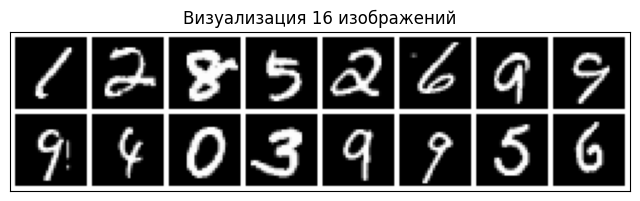

In [4]:
SHOW_N_IMAGES = 16

images, _ = next(iter(train_loader))
print("Форма батча изображений:", images.shape)
print("Минимум / максимум: ", images.min(), images.max())

show_images(
    images=images[:SHOW_N_IMAGES],
    title=f"Визуализация {SHOW_N_IMAGES} изображений",
)

**Интерпретация:**  

Всего в данных 70_000 изображений: `60_000 обучающая` выборка, `10_000 тестовая`. Данные нормированы в диапозоне `[0, 1]`, что позволит получить между выходом декодера и оригиналом низкий MSE, улучшив обучение модели и её сходимость. Размерность батча данных `(128, 1, 28, 28)` - в дальнейшей работе потребуется развернуть в вектор `(128, 784)`.

### Реализация и обучение простого автоэнкодера

In [5]:
class SimpleAutoencoder(nn.Module):
    def __init__(
        self,
        input: int = 784,
        hidden: int = 392,
        latent_dim: int = 32,
    ) -> None:
        super().__init__()

        assert input > latent_dim, (
            "Размерность латентного представления должна быть "
            "меньше размерности входных признаков"
        )

        self.encoder = nn.Sequential(
            nn.Linear(input, hidden),
            nn.ReLU(),
            nn.Linear(hidden, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, input),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

def train_model(
    model: nn.Module,
    epochs: int = 10,
    verbose: int = 1,
) -> tuple[nn.Module, list[float]]:
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_history = []
    for epoch in range(1, epochs + 1):
        model.train()

        train_loss_batch = []
        for images, _ in train_loader:
            optimizer.zero_grad()

            images = images.view(images.size(0), -1)
            x_hat = model(images)
            loss = criterion(x_hat, images)

            loss.backward()
            optimizer.step()

            train_loss_batch.append(loss.item())

        batch_loss = np.mean(train_loss_batch)
        train_loss_history.append(batch_loss)

        if not epoch % verbose:
            print(f"Эпоха {epoch}/{epochs}: MSE {batch_loss:.4f}")
    
    return model, train_loss_history

latent_dim = 32
ae_model = SimpleAutoencoder(latent_dim=latent_dim)

epochs = 5
model, train_loss_history = train_model(ae_model, epochs)

Эпоха 1/5: MSE 0.0354
Эпоха 2/5: MSE 0.0126
Эпоха 3/5: MSE 0.0095
Эпоха 4/5: MSE 0.0083
Эпоха 5/5: MSE 0.0075


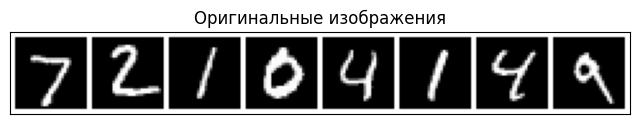

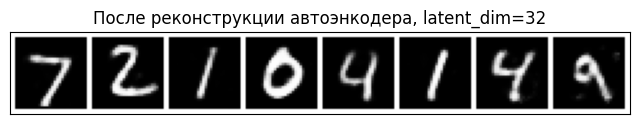

In [6]:
SHOW_N_TEST_IMAGES = 8

test_images, _ = next(iter(test_loader))

test_images_flat = test_images.view(test_images.size(0), -1)
test_images_hat = ae_model(test_images_flat)
test_images_ae = test_images_hat.view(-1, 1, 28, 28)

show_images(
    images=test_images[:SHOW_N_TEST_IMAGES],
    title="Оригинальные изображения",
)

show_images(
    images=test_images_ae[:SHOW_N_TEST_IMAGES],
    title=f"После реконструкции автоэнкодера, {latent_dim=}",
)

**Интерпретация:**  

После пропуска оригинальных изображений через автоэнкодер, четкость итоговых изображений снизилась, но контуры цифр прослеживаются явно. При входе в 784 и латентной размерности 32, энкодер сжимает изображение почти в 25 раз, отбрасывая детали и сохраняя только самые важные признаки.

### Анализ динамики ошибки автоэнкодера

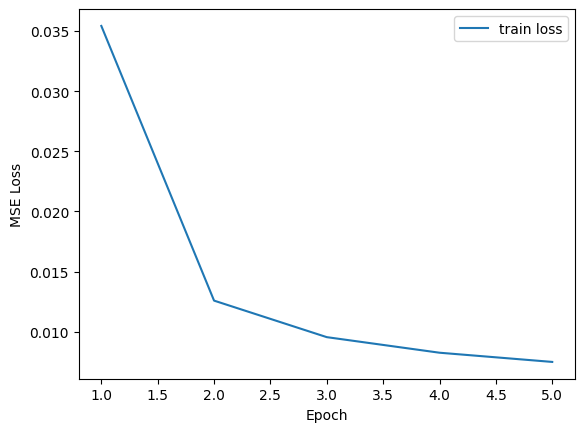

In [7]:
sns.lineplot(x=range(1, epochs + 1), y=train_loss_history, label="train loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.show()

**Интерпретация:**  

Кривая ошибки показывает нормальное поведение, с ожидаемой динамикой при правильном параметре скорости обучения и архитектуры модели в целом. В идеале, дополнить бы график кривой валидационной выборки, чтобы понимать, в какой момент наступает переобучение и требуется вмешательство в виде регуляризации или ранней остановки.

### Визуализация латентного пространства автоэнкодера

In [8]:
ae_2d = SimpleAutoencoder(latent_dim=2)
ae_2d, _ = train_model(ae_2d, epochs=5, verbose=1)

latents = []
labels_list = []
with torch.no_grad():
    for images, labels in test_loader:
        z = ae_2d.encoder(images.view(images.size(0), -1))
        latents.append(z)
        labels_list.append(labels)

latents = torch.cat(latents, dim=0)
labels_list = torch.cat(labels_list, dim=0)

Эпоха 1/5: MSE 0.0573
Эпоха 2/5: MSE 0.0485
Эпоха 3/5: MSE 0.0464
Эпоха 4/5: MSE 0.0453
Эпоха 5/5: MSE 0.0445


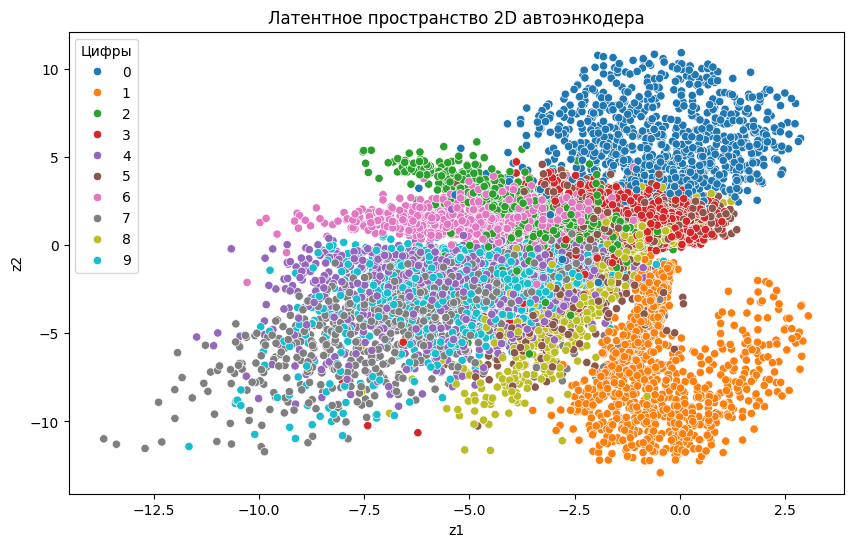

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=latents[:, 0],
    y=latents[:, 1],
    hue=labels_list,
    palette="tab10",
)

plt.title("Латентное пространство 2D автоэнкодера")
plt.legend(title="Цифры")
plt.xlabel("z1")
plt.ylabel("z2")

plt.show()

**Интерпретация:**  

При использовании двумерного латентного пространства в автоэнкодере визуализация на scatterplot демонстрирует разделение, похожее на кластеризацию по классам, хотя энкодер не обучается с учителем. Однако, энкодер замечает схожесть структуры цифр, поэтому некоторые пары расположены близко или пересекаются на графике (3/8, 4/9).

### Реализация и обучение вариационного автоэнкодера (VAE)

In [10]:
class VAE(nn.Module):
    def __init__(
        self,
        input: int = 784,
        hidden: int = 392,
        latent_dim: int = 32,
    ) -> None:
        super().__init__()

        assert input > latent_dim, (
            "Размерность латентного представления должна быть "
            "меньше размерности входных признаков"
        )

        self.encoder = nn.Sequential(
            nn.Linear(input, hidden),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(hidden, latent_dim)
        self.fc_logvar = nn.Linear(hidden, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, input),
            nn.Sigmoid(),
        )

    def encode(
        self,
        x: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        x_hat = self.encoder(x)
        mu = self.fc_mu(x_hat)
        logvar = self.fc_logvar(x_hat)
        return mu, logvar

    def reparameterize(
        self,
        mu: torch.Tensor,
        logvar: torch.Tensor,
    ) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def forward(
        self,
        x: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

def get_vae_kl(
    mu: torch.Tensor,
    logvar: torch.Tensor,
) -> torch.Tensor:
    return 0.5 * torch.mean(torch.sum(
        torch.square(mu) + torch.exp(logvar) - logvar - 1.0,
        dim=1,
    ))

vae_model = VAE(latent_dim=32)
criterion = nn.MSELoss(reduction="sum")
optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

epochs = 5
verbose = 1
beta = 1.0
vae_loss_history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
}
for epoch in range(1, epochs + 1):
    vae_model.train()
    
    train_loss_batch = []
    train_recon_batch = []
    train_kl_batch = []
    for images, _ in train_loader:
        optimizer.zero_grad()
        
        images = images.view(images.size(0), -1)
        x_recon, mu, logvar = vae_model(images)
        
        recon = criterion(x_recon, images)

        kl = get_vae_kl(mu, logvar)

        loss = recon + kl * beta
        
        loss.backward()
        optimizer.step()
        
        train_recon_batch.append(recon.item())
        train_kl_batch.append(kl.item())
        train_loss_batch.append(loss.item())
        
    train_loss_epoch = np.mean(train_loss_batch)
    train_recon_epoch = np.mean(train_recon_batch)
    train_kl_epoch = np.mean(train_kl_batch)

    vae_loss_history["train_loss"].append(train_loss_epoch)
    vae_loss_history["train_recon"].append(train_recon_epoch)
    vae_loss_history["train_kl"].append(train_kl_epoch)

    if not epoch % verbose:
        print(
            f"Эпоха {epoch}/{epochs}: "
            f"{train_loss_epoch=:.2f} "
            f"{train_recon_epoch=:.2f} "
            f"{train_kl_epoch=:.2f}"
        )

Эпоха 1/5: train_loss_epoch=3546.94 train_recon_epoch=3438.74 train_kl_epoch=108.20
Эпоха 2/5: train_loss_epoch=1376.97 train_recon_epoch=1248.27 train_kl_epoch=128.70
Эпоха 3/5: train_loss_epoch=1054.51 train_recon_epoch=932.63 train_kl_epoch=121.88
Эпоха 4/5: train_loss_epoch=917.32 train_recon_epoch=801.00 train_kl_epoch=116.32
Эпоха 5/5: train_loss_epoch=836.34 train_recon_epoch=723.63 train_kl_epoch=112.71


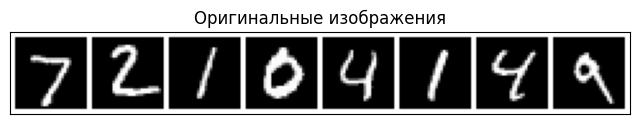

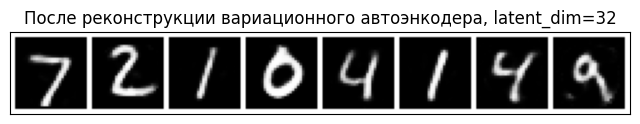

In [11]:
test_images_flat = test_images.view(test_images.size(0), -1)
test_images_hat, *_ = vae_model(test_images_flat)
test_images_vae = test_images_hat.view(-1, 1, 28, 28)

show_images(
    images=test_images[:SHOW_N_TEST_IMAGES],
    title="Оригинальные изображения",
)

show_images(
    images=test_images_vae[:SHOW_N_TEST_IMAGES],
    title=f"После реконструкции вариационного автоэнкодера, {latent_dim=}",
)

**Интерпретация:**  

`train_recon` убывает, то есть модель учится лучше восстанавливать входные данные. В то же время, `train_kl` изменяется в небольшом интервале, не выходя в ноль - модель старается найти компромисс между точностью реконструкции и структурированностью латентного пространства.

### Сравнение реконструкций AE и VAE на одних и тех же примерах

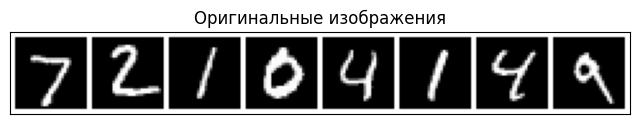

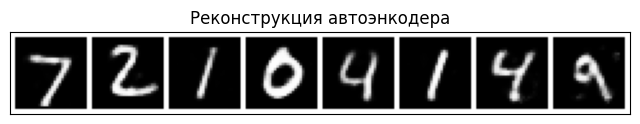

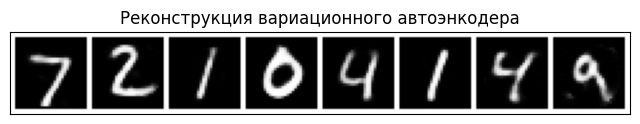

In [12]:
with torch.no_grad():
    test_images_flat = test_images.view(test_images.size(0), -1)
    
    ae_recon = ae_model(test_images_flat)
    test_images_ae = ae_recon.view(-1, 1, 28, 28)

    vae_recon, _, _ = vae_model(test_images_flat)
    test_images_vae = vae_recon.view(-1, 1, 28, 28)

show_images(
    images=test_images[:SHOW_N_TEST_IMAGES],
    title="Оригинальные изображения",
)

show_images(
    images=test_images_ae[:SHOW_N_TEST_IMAGES],
    title="Реконструкция автоэнкодера",
)

show_images(
    images=test_images_vae[:SHOW_N_TEST_IMAGES],
    title="Реконструкция вариационного автоэнкодера",
)

**Интерпретация:**  

Реконструкция вариационного автоэнкодера выглядит чуть более размытой, чем у обычного энкодера, хотя это не совсем учевидно. С другой стороны, так и должно быть, ведь VAE жертвует точностью реконструкции для гладкого латента, когда для AE учитывается строго ошибка реконструкции.

### Интерполяция в латентном пространстве VAE

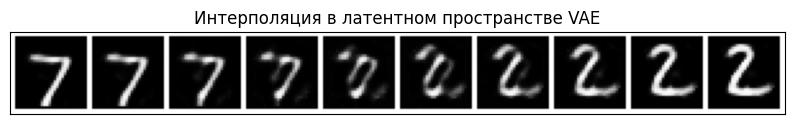

In [13]:
img1, img2 = test_images[0], test_images[1]

with torch.no_grad():
    mu1, _ = vae_model.encode(img1.view(1, -1))
    mu2, _ = vae_model.encode(img2.view(1, -1))

STEPS = 10
alphas = torch.linspace(0, 1, steps=STEPS)

images_interp = []
for alpha in alphas:
    z_interp = (1 - alpha) * mu1 + alpha * mu2
    x_interp = vae_model.decoder(z_interp).view(-1, 1, 28, 28)
    images_interp.append(x_interp)

images_interp = torch.cat(images_interp, dim=0)

show_images(
    images=images_interp,
    title="Интерполяция в латентном пространстве VAE",
    nrow=STEPS,
)

**Интерпретация:**  

На визуализации видно, что при движении по отрезку в латентном пространстве небольшие изменения кода приводят к плавным, осмысленным изменениям объекта.

### Генерация новых примеров из латентного пространства

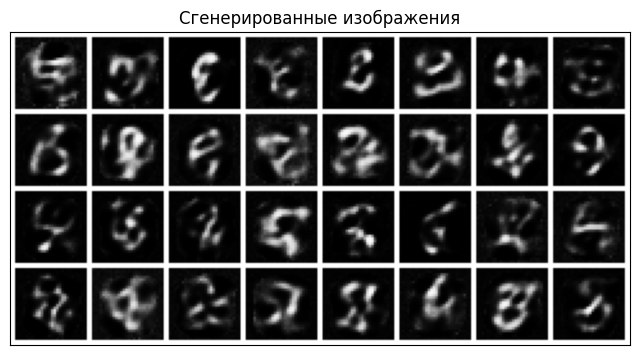

In [30]:
z_samples = torch.randn(32, latent_dim)

with torch.no_grad():
    generated = vae_model.decoder(z_samples)

show_images(
    images=generated.view(-1, 1, 28, 28),
    title="Сгенерированные изображения",
)

### Количественное сравнение AE и VAE

In [15]:
with torch.no_grad():
    ae_model.eval()
    vae_model.eval()
    
    ae_mse, vae_mse = [], []
    for _ in range(epochs):

        ae_batch_loss, vae_batch_loss = [], []
        for images, _ in test_loader:
            images = images.view(images.size(0), -1)
            
            ae_recon = ae_model(images)
            ae_loss = F.mse_loss(ae_recon, images)
            ae_batch_loss.append(ae_loss.item())

            vae_recon, *_ = vae_model(images)
            vae_loss = F.mse_loss(vae_recon, images)
            vae_batch_loss.append(vae_loss.item())
        
        ae_mse.append(np.mean(ae_batch_loss))
        vae_mse.append(np.mean(vae_batch_loss))

ae_mse = np.mean(ae_mse)
vae_mse = np.mean(vae_mse)

print(f"AE MSE: {ae_mse:.4f}")
print(f"VAE MSE: {vae_mse:.4f}")

AE MSE: 0.0070
VAE MSE: 0.0068


In [31]:
def avg_pair_dist(X: torch.Tensor, n_pairs: int = 1000) -> float:
    rows, _ = X.shape
    indx_1 = np.random.randint(0, rows, n_pairs)
    indx_2 = np.random.randint(0, rows, n_pairs)
    diff = X[indx_1] - X[indx_2]
    dist = np.linalg.norm(diff, axis=1)
    return dist.mean()

with torch.no_grad():
    ae_sample = ae_model.decoder(torch.randn(32, latent_dim))
    vae_sample = vae_model.decoder(torch.randn(32, latent_dim))

diversity_ae = avg_pair_dist(ae_sample.view(latent_dim, -1))
diversity_vae = avg_pair_dist(vae_sample.view(latent_dim, -1))

print(f"AE diversity: {diversity_ae:.4f}")
print(f"VAE diversity: {diversity_vae:.4f}")

AE diversity: 3.7258
VAE diversity: 6.4283


**Интерпретация:**  

Два энкодера показывают очень близкое значение MSE, хотя значение для VAE должено быть несколько большим, чем у AE, так как последний оптимизирует только этот параметр.  

Однако, VAE выигрывает по разнообразию сэмплов и качеству латентного пространства.